In [13]:
from pathlib import Path
import pygimli as pg  # Stelle sicher, dass das Modul pg importiert ist und verfügbar ist
from pygimli.physics import ert
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from datetime import datetime
import os
import numpy as np
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
import matplotlib.ticker as mticker

from Hilfsfunktionen import T_corr_nach_Inversion
from Hilfsfunktionen import plotting_function
from Hilfsfunktionen import plotting_function_FTL

# Read data
file = "two_timesteps.ohm"
base_dir = Path("filtered_data")
data = []
for unterordner in base_dir.iterdir():
    if unterordner.is_dir():
        datei_pfad = unterordner / "two_timesteps.ohm" 
        if datei_pfad.exists():
            daten_objekt = pg.load(str(datei_pfad))
            data.append([unterordner.name, daten_objekt])
            print(f"Load data: {datei_pfad}")

# Create method manager
manager = []
for ts in data:
    manager.append(ert.ERTManager(ts[1], verbose=True))

Load data: filtered_data\240710\two_timesteps.ohm
Load data: filtered_data\240808\two_timesteps.ohm


In [14]:
# Create mesh
mesh = manager[0].createMesh(quality = 34, paraMaxCellSize=0.5, paraDepth=15)
#manager[0].invert(quality = 34, paraMaxCellSize=0.5, maxIter=1 ,dPhi= 0.1, paraDepth=15,lam=20)

01/09/25 - 00:06:13 - pyGIMLi - INFO - Found 2 regions.
01/09/25 - 00:06:13 - pyGIMLi - INFO - (ERTModelling) Region with smallest marker (1) set to background.


In [17]:
scalef_list = np.linspace(0.05, 1.9, num=30)
scalef_list

array([0.05      , 0.1137931 , 0.17758621, 0.24137931, 0.30517241,
       0.36896552, 0.43275862, 0.49655172, 0.56034483, 0.62413793,
       0.68793103, 0.75172414, 0.81551724, 0.87931034, 0.94310345,
       1.00689655, 1.07068966, 1.13448276, 1.19827586, 1.26206897,
       1.32586207, 1.38965517, 1.45344828, 1.51724138, 1.58103448,
       1.64482759, 1.70862069, 1.77241379, 1.8362069 , 1.9       ])

In [18]:
# FTL
manager_list_tl = []
# ScaleF-Liste
scalef_list = np.linspace(0.05, 1.9, num=30)



results_tl_diff = []
chi2_dict_FTL      = []
phi_m_dict_FTL     = []
phi_d_dict_FTL     = []
rms_dict_FTL       = []
rrms_dict_FTL      = []
phi_m_zeitlich     = []


# Inversion without temperature correction
DATA = [dat[1] for dat in data]
# Full time-lapse
for scalef in scalef_list:
    fop = pg.frameworks.MultiFrameModelling(ert.ERTModelling, scalef=scalef)
    fop.setData(DATA)
    fop.setMesh(mesh)
    print(fop.mesh()) 
    dataVec = np.concatenate([data["rhoa"] for data in DATA])
    errorVec = np.concatenate([data["err"] for data in DATA])
    startModel = fop.createStartModel(dataVec)
    inv = pg.Inversion(fop=fop, startModel=startModel, verbose=True)
    model = inv.run(dataVec, errorVec, maxIter=10, lam= 15, startModel=startModel,stopAtChi1=False, verbose=True)
    chi2 = []
    rrms = []
    chi2.append(round(inv.chi2(),2))
    rrms.append(round(inv.relrms(),2))
    mod = np.reshape(model, [len(DATA), -1])

    # Zeitliche Roughness berechnen
    m = np.array(inv.model)          # Länge 6208
    n = m.size // 2                    # Zellen je Zeitschritt = 3104
    m1 = m[:n]                         # Schritt 1
    m2 = m[n:]                         # Schritt 2
    
    # falls m bereits log(ρ) wäre: die nächste Zeile weglassen!
    dlog = np.log(m2) - np.log(m1)     # Differenz in log(ρ)
    
    MT = np.sum(dlog**2)               # zeitliche Rauigkeit (L2)

    
    chi2_dict_FTL.append(inv.chi2())
    phi_m_zeitlich.append(MT)
    phi_d_dict_FTL.append(inv.phiData())
    phi_m_dict_FTL.append(inv.phiModel())
    rrms_dict_FTL.append(round(inv.relrms(), 2))
    rms_dict_FTL.append(round(inv.absrms(), 2))


01/09/25 - 00:07:06 - pyGIMLi - INFO - Found 2 regions.
01/09/25 - 00:07:06 - pyGIMLi - INFO - Region with smallest marker (1) set to background
01/09/25 - 00:07:06 - pyGIMLi - INFO - Creating forward mesh from region infos.
01/09/25 - 00:07:06 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
01/09/25 - 00:07:07 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 8540 Cells: 16788 Boundaries: 12736


3104 model cells
Mesh: Nodes: 8540 Cells: 16788 Boundaries: 12736


01/09/25 - 00:07:19 - pyGIMLi - INFO - Starting inversion.


fop: <pygimli.frameworks.timelapse.MultiFrameModelling object at 0x000002B1EB3E4FE0>
Data transformation: <pgcore._pygimli_.RTrans object at 0x000002B13B7F4BA0>
Model transformation: <pgcore._pygimli_.RTransLog object at 0x000002B1EB3FE7A0>
min/max (data): 65.6/6396
min/max (error): 3%/3.02%
min/max (start model): 1951/1951
--------------------------------------------------------------------------------
inv.iter 0 ... chi² = 17958.28
--------------------------------------------------------------------------------
inv.iter 1 ... chi² =  416.75 (dPhi = 97.65%) lam: 15.0
--------------------------------------------------------------------------------
inv.iter 2 ... chi² =  144.54 (dPhi = 65.18%) lam: 15.0
--------------------------------------------------------------------------------
inv.iter 3 ... chi² =    3.05 (dPhi = 96.31%) lam: 15.0
--------------------------------------------------------------------------------
inv.iter 4 ... chi² =    2.17 (dPhi = 20.07%) lam: 15.0
--------------

01/09/25 - 00:12:52 - pyGIMLi - INFO - Found 2 regions.
01/09/25 - 00:12:52 - pyGIMLi - INFO - Region with smallest marker (1) set to background
01/09/25 - 00:12:52 - pyGIMLi - INFO - Creating forward mesh from region infos.


...

chi² =    1.57 (dPhi = 0.77%) lam: 15.0
################################################################################
#                Abort criterion reached: dPhi = 0.77 (< 2.0%)                 #
################################################################################


01/09/25 - 02:48:58 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
01/09/25 - 02:48:58 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 8540 Cells: 16788 Boundaries: 12736


3104 model cells
Mesh: Nodes: 8540 Cells: 16788 Boundaries: 12736


01/09/25 - 02:49:01 - pyGIMLi - INFO - Starting inversion.


fop: <pygimli.frameworks.timelapse.MultiFrameModelling object at 0x000002B155C62520>
Data transformation: <pgcore._pygimli_.RTrans object at 0x000002B150E63300>
Model transformation: <pgcore._pygimli_.RTransLog object at 0x000002B17FB23F10>
min/max (data): 65.6/6396
min/max (error): 3%/3.02%
min/max (start model): 1951/1951
--------------------------------------------------------------------------------
inv.iter 0 ... chi² = 17958.28
--------------------------------------------------------------------------------
inv.iter 1 ... chi² =  412.33 (dPhi = 97.67%) lam: 15.0
--------------------------------------------------------------------------------
inv.iter 2 ... chi² =  149.39 (dPhi = 63.55%) lam: 15.0
--------------------------------------------------------------------------------
inv.iter 3 ... chi² =    3.25 (dPhi = 95.73%) lam: 15.0
--------------------------------------------------------------------------------
inv.iter 4 ... chi² =    2.40 (dPhi = 16.21%) lam: 15.0
--------------

In [23]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import UnivariateSpline
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D

def plot_l_curve(phi_m_list, phi_d_list, lam_list, spline_s=0.001, fontsize=14, save_path=None):
    """
    L-Curve Plot mit Curvature und Maximum Curvature Annotation.

    Parameters:
    -----------
    phi_m_list : array-like
        Liste der Modell-Roughness-Werte (Φₘ).
    phi_d_list : array-like
        Liste der Daten-Misfit-Werte (Φ_d).
    lam_list : array-like
        Liste der Regularisierungsparameter λ.
    spline_s : float
        Glättungsfaktor für UnivariateSpline (default=0.001).
    fontsize : int
        Schriftgröße für Achsen, Titel, Legende und Annotation.
    """
    fig, ax1 = plt.subplots(1, 1, figsize=(8,6))

    # ==========================
    # L-Curve Plot
    # ==========================
    ax1.plot(phi_m_list, phi_d_list, color='black', marker='o', alpha=0.5, linestyle='')

    sc = ax1.scatter(phi_m_list, phi_d_list,
                     c=lam_list,
                     cmap='jet',
                     norm=mcolors.LogNorm(vmin=min(lam_list), vmax=max(lam_list)),
                     s=60,
                     edgecolor='black',
                     zorder=3)

    cbar = fig.colorbar(sc, ax=ax1)
    cbar.set_label("Regularization parameter sf", fontsize=fontsize)
    num_ticks = 6
    tick_values = np.logspace(np.log10(min(lam_list)), np.log10(max(lam_list)), num=num_ticks)
    cbar.locator = mticker.FixedLocator(tick_values)
    cbar.ax.set_yticklabels([f"{val:.3g}" for val in tick_values], fontsize=fontsize)
    cbar.ax.minorticks_off()

    ax1.set_xlabel("Temporal model roughness Φₘ", fontsize=fontsize)
    ax1.set_ylabel("Data misfit Φ_d (χ²)", fontsize=fontsize)
    ax1.set_title("L-curve FTL", fontsize=fontsize+2)

    # Tick-Labels größer machen
    ax1.tick_params(axis='both', labelsize=fontsize)

    # ==========================
    # Krümmung berechnen
    # ==========================
    x = (phi_m_list - np.min(phi_m_list)) / (np.max(phi_m_list) - np.min(phi_m_list))
    y = (phi_d_list - np.min(phi_d_list)) / (np.max(phi_d_list) - np.min(phi_d_list))
    t = np.arange(len(x))

    spl_x = UnivariateSpline(t, x, k=3, s=spline_s*len(t))
    spl_y = UnivariateSpline(t, y, k=3, s=spline_s*len(t))

    dx_disc, ddx_disc = spl_x.derivative(1)(t), spl_x.derivative(2)(t)
    dy_disc, ddy_disc = spl_y.derivative(1)(t), spl_y.derivative(2)(t)
    curv_disc = np.abs(dx_disc*ddy_disc - dy_disc*ddx_disc) / (dx_disc**2 + dy_disc**2)**1.5

    # ==========================
    # Zweite Achse für Curvature ohne Beschriftung
    # ==========================
    ax1_curv = ax1.twinx()
    ax1_curv.set_ylabel('')               
    ax1_curv.set_yticklabels([])          
    ax1_curv.tick_params(axis='y', length=5)  

    # Kreuze auf Curvature-Höhe, letzte 10 Punkte weggeschnitten
    phi_m_plot = phi_m_list[:-15]
    curv_plot = curv_disc[:-15]

    ax1_curv.scatter(phi_m_plot, curv_plot,
                     s=60,
                     marker='x',
                     color='black')

    # ==========================
    # Eine gemeinsame Legende (Kreise + Kreuze)
    # ==========================
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', label='L-Curve', markerfacecolor='black', markersize=8, alpha=0.5, linestyle='None'),
        Line2D([0], [0], marker='x', color='black', label='Curvature', markersize=8, linestyle='None')
    ]
    ax1.legend(handles=legend_elements, loc='upper right', fontsize=fontsize)

    # ==========================
    # Maximalpunkt markieren mit Pfeil von rechts oben
    # ==========================
    idx_max_curv = np.argmax(curv_plot)
    phi_m_max = phi_m_plot[idx_max_curv]
    curv_max = curv_plot[idx_max_curv]
    lam_max = lam_list[idx_max_curv]

    ax1_curv.annotate(f"Maximum curvature\nat sf={lam_max:.3f}",
                     xy=(phi_m_max+2, curv_max),
                     xytext=(phi_m_max + 30, curv_max*0.75),
                     arrowprops=dict(facecolor='black', arrowstyle="->"),
                     ha='center',
                     color='black',
                     fontsize=fontsize)
    #
    plt.tight_layout()
    # ==========================
    # Optional speichern
    # ==========================
    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Figure saved to {save_path}")

    plt.show()


Figure saved to ./L_curve_FTL/L-Curve_zwei_Zeitschritte_gute_Darstellung_groesser_neu.png


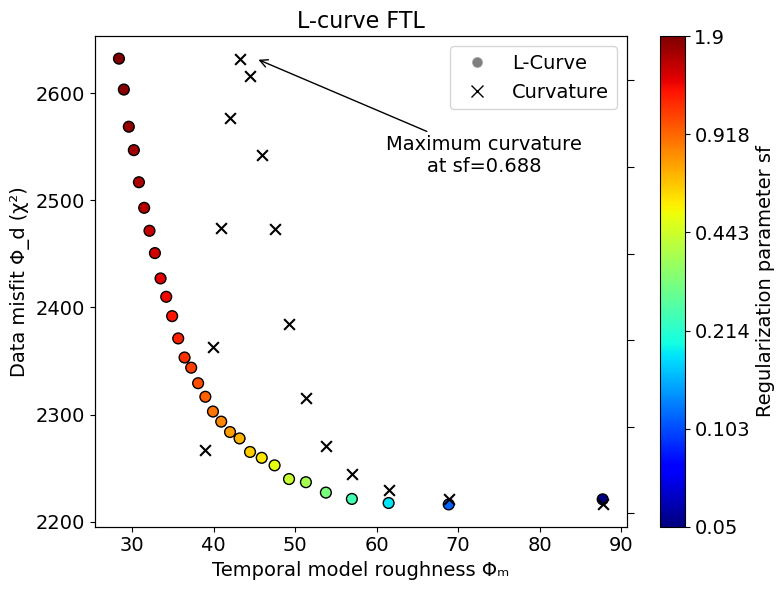

In [24]:
plot_l_curve(phi_m_zeitlich, phi_d_dict_FTL, scalef_list, spline_s=0.001, fontsize=14, save_path='./L_curve_FTL/L-Curve_zwei_Zeitschritte_gute_Darstellung_groesser_neu.png')

#np.save('./L_curve_FTL/L-Curve_zwei_Zeitschritte_phi_m_zeitlich.npy', phi_m_zeitlich)
#np.save('./L_curve_FTL/L-Curve_zwei_Zeitschritte_phi_d_mean_new_2.npy', phi_d_dict_FTL)
#np.save('./L_curve_FTL/L-Curve_zwei_Zeitschritte_scalef_list_2.npy', scalef_list)

Figure saved to ./L_curve_FTL/L-Curve_zwei_Zeitschritte_gute_Darstellung_groesser_neu.png


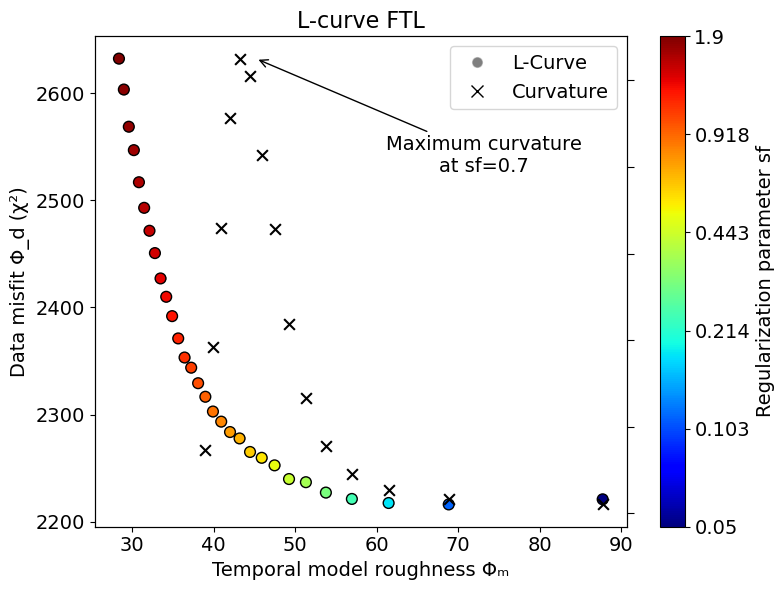

In [21]:
plot_l_curve(phi_m_zeitlich, phi_d_dict_FTL, scalef_list, spline_s=0.001, fontsize=14, save_path='./L_curve_FTL/L-Curve_zwei_Zeitschritte_gute_Darstellung_groesser_neu.png')

np.save('./L_curve_FTL/L-Curve_zwei_Zeitschritte_phi_m_zeitlich_3.npy', phi_m_zeitlich)
np.save('./L_curve_FTL/L-Curve_zwei_Zeitschritte_phi_d_mean_new_3.npy', phi_d_dict_FTL)
np.save('./L_curve_FTL/L-Curve_zwei_Zeitschritte_scalef_list_2.npy', scalef_list)

In [22]:
scalef_list

array([0.05      , 0.1137931 , 0.17758621, 0.24137931, 0.30517241,
       0.36896552, 0.43275862, 0.49655172, 0.56034483, 0.62413793,
       0.68793103, 0.75172414, 0.81551724, 0.87931034, 0.94310345,
       1.00689655, 1.07068966, 1.13448276, 1.19827586, 1.26206897,
       1.32586207, 1.38965517, 1.45344828, 1.51724138, 1.58103448,
       1.64482759, 1.70862069, 1.77241379, 1.8362069 , 1.9       ])

22/08/25 - 23:26:55 - matplotlib.legend - WARNING - No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


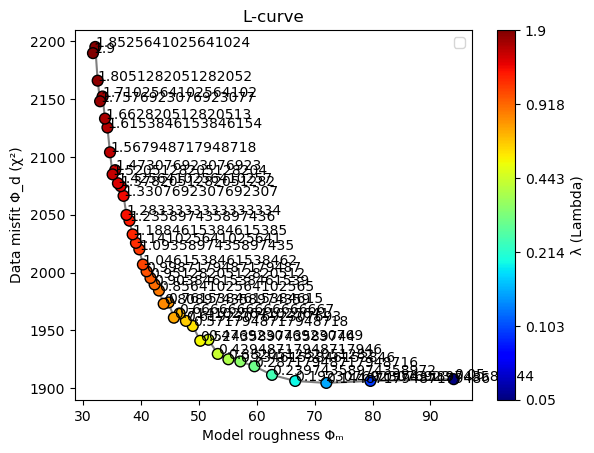

In [39]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
import matplotlib.ticker as mticker

# alle Kurven plotten
plt.plot(phi_m_zeitlich, phi_d_dict_FTL, color='black', marker='o', alpha=0.5)


# Punkte der Mittelkurve einfärben nach lam_list
sc = plt.scatter(phi_m_zeitlich, phi_d_dict_FTL,
                 c=scalef_list,                # Werte für die Farbskala
                 cmap='jet',
                 norm=mcolors.LogNorm(vmin=min(scalef_list), vmax=max(scalef_list)),  # LOG-Skala# Colormap (z.B. plasma, inferno, jet, etc.)
                 s=60,                      # Punktgröße
                 edgecolor='black',         # optional: schwarze Umrandung
                 zorder=3)
for lam, x, y in zip(scalef_list, phi_m_zeitlich, phi_d_dict_FTL):
    plt.text(x, y, str(lam))

# Farbskala hinzufügen
cbar = plt.colorbar(sc)
cbar.set_label("λ (Lambda)")

num_ticks = 6  # z.B. 6 Ticks
tick_values = np.logspace(np.log10(min(scalef_list)), np.log10(max(scalef_list)), num=num_ticks)
cbar.locator = mticker.FixedLocator(tick_values)
cbar.ax.set_yticklabels([f"{val:.3g}" for val in tick_values])  # formatieren, z.B. 3 sign. Stellen
cbar.ax.minorticks_off()

# Achsenbeschriftung und Titel
plt.xlabel("Model roughness Φₘ")
plt.ylabel("Data misfit Φ_d (χ²)")
plt.title("L-curve")
plt.legend()
plt.savefig('./L_curve_FTL/L-Curve_FTL.png', bbox_inches = 'tight', dpi=300)
np.save('./L_curve_FTL/phi_m_mean.npy', phi_m_zeitlich)
np.save('./L_curve_FTL/phi_d_mean.npy', phi_d_dict_FTL)
np.save('./L_curve_FTL/scalef_values.npy', scalef_list)
plt.show()


In [17]:
phi_m_dict_FTL

[270.0878450388809,
 270.10771334563213,
 270.22079648504086,
 270.2721104492492,
 270.461302269321,
 270.84156189822335,
 271.24911182114283,
 271.8009556445072,
 272.5854837787456,
 273.7093103935544,
 275.28198093993313,
 277.64565859569564,
 280.93447613718143,
 285.2915602729659,
 291.84394314764876,
 301.2319719367188,
 313.8228507082275,
 330.805867267495,
 353.55609139412746,
 383.31237822146454]